In [43]:
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.ndimage import gaussian_filter

NumOfPoints = 64
sigmaGauss = 1.6

from data_generation import generate_pulses_gaussian as _generate_pulses_gaussian_shared


def generate_pulses_gaussian(N, dt, sigma_omega, num_points=NumOfPoints, sigma=sigmaGauss, phase_scale=np.pi):
    """
    עטיפה לפונקציה המשותפת ב-data_generation.py.
    שומרת על אותה חתימה כדי לא לשבור תאים קיימים במחברת.
    """
    return _generate_pulses_gaussian_shared(
        n_pulses=N,
        dt=dt,
        sigma_omega=sigma_omega,
        num_points=num_points,
        sigma=sigma,
        phase_scale=phase_scale,
        seed=None,
    )

In [44]:
# ==========================================
# הפעלת הקוד והצגת התוצאות
# ==========================================

# הגדרת פרמטרים פיזיקליים
N_pulses = 300
t_total = 250.0
dt_as = t_total / NumOfPoints  # A time window of "t_total" attoseconds divided into "NumOfPoints" points
sigma_w = 0.05*(2*np.pi/dt_as) # sigma_w is the Gaussian bandwidth (example of physical value). it must be smaller than the total spectral range, (2*Pi/dt_as). 

# ייצור הנתונים
dataset_t, dataset_w, t_vec, w_vec = generate_pulses_gaussian(
    N=N_pulses,
    dt=dt_as,
    sigma_omega=sigma_w,
    sigma=sigmaGauss
)

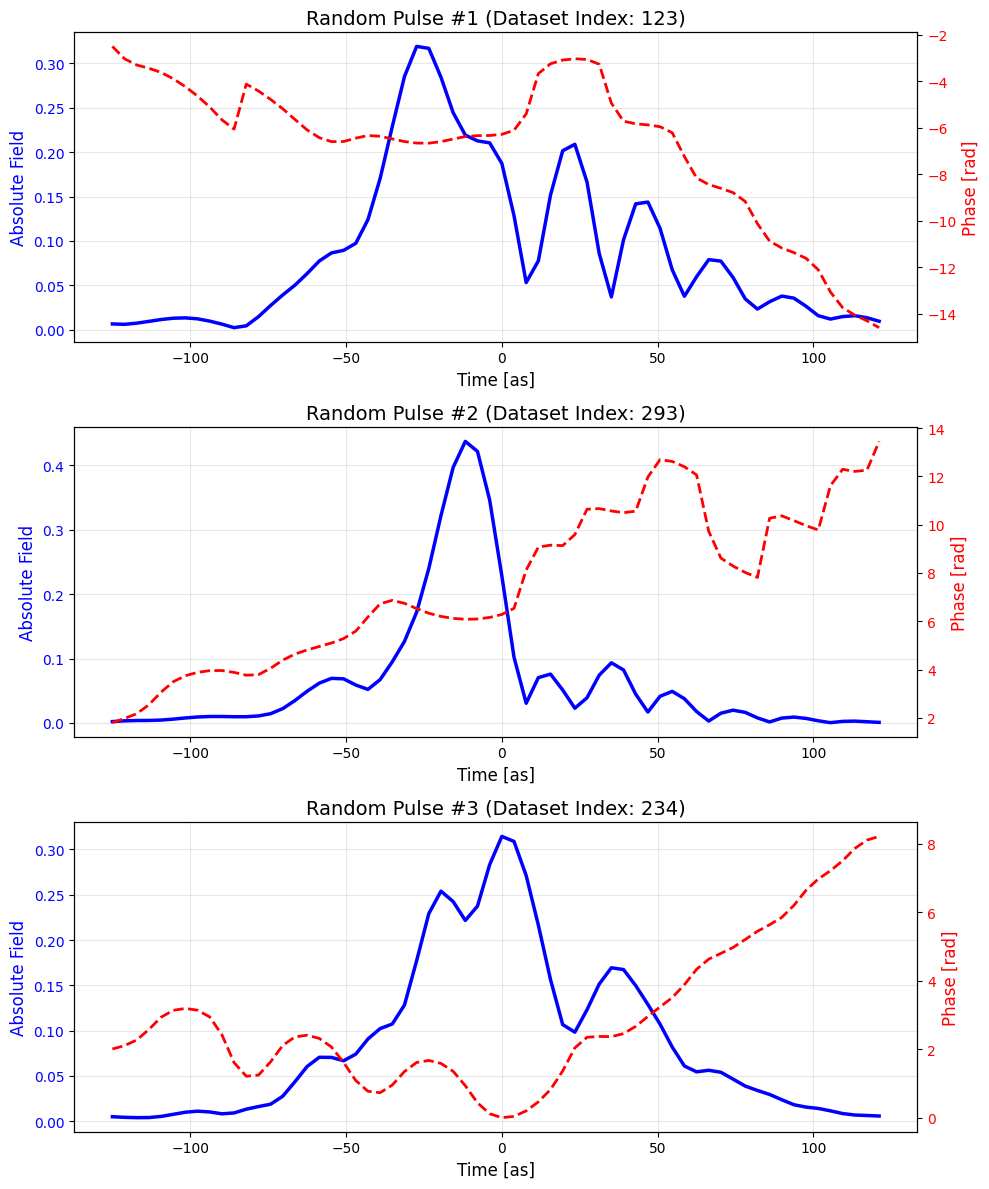

In [45]:
# שליפת 3 אינדקסים אקראיים מתוך המאגר
random_indices = random.sample(range(N_pulses), 3)

# יצירת גרפים להצגת 3 הפולסים שנבחרו במרחב הזמן
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

for i, idx in enumerate(random_indices):
    pulse_t = dataset_t[idx]

    # חישוב האמפליטודה והפאזה
    amplitude = np.abs(pulse_t)
    phase = np.unwrap(np.angle(pulse_t))

    ax1 = axes[i]
    ax2 = ax1.twinx()

    # שרטוט האמפליטודה כנגד ציר הזמן הפיזיקלי (t_vec)
    ax1.plot(t_vec, amplitude, color='blue', linewidth=2.5, label='Absolute Field [a.u]')
    ax1.set_ylabel('Absolute Field', color='blue', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='blue')

    # שרטוט הפאזה כנגד ציר הזמן הפיזיקלי (t_vec)
    ax2.plot(t_vec, phase, color='red', linestyle='--', linewidth=2, label='Phase [rad]')
    ax2.set_ylabel('Phase [rad]', color='red', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='red')

    ax1.set_title(f'Random Pulse #{i+1} (Dataset Index: {idx})', fontsize=14)
    # כעת ציר ה-X מציג יחידות זמן אמיתיות
    ax1.set_xlabel('Time [as]', fontsize=12)
    ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

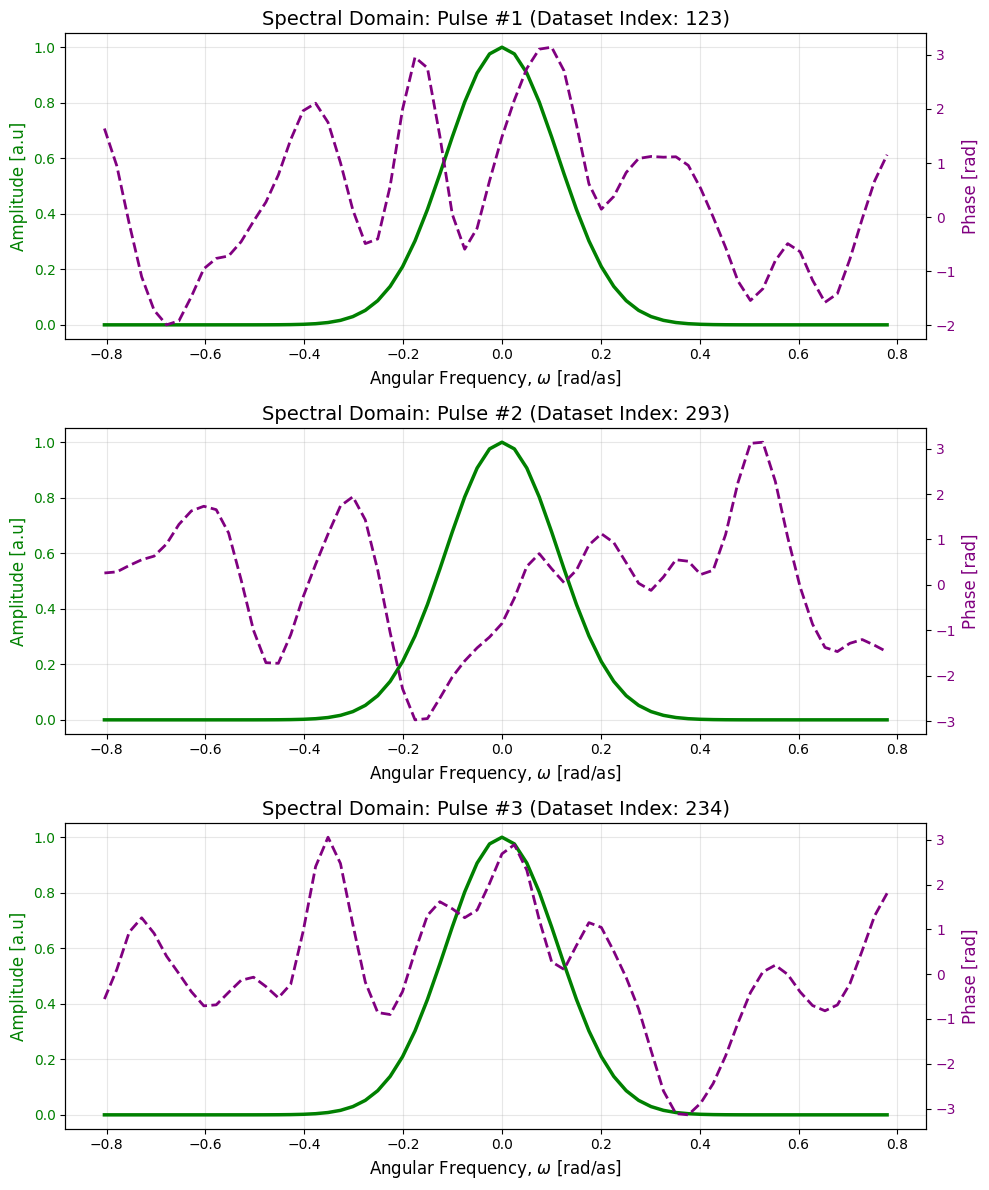

In [46]:
# ==========================================
# שרטוט הפולסים במרחב התדר (ספקטרלי)
# ==========================================
fig_w, axes_w = plt.subplots(3, 1, figsize=(10, 12))

for i, idx in enumerate(random_indices):
    # שליפת אותו הפולס, אך במרחב התדר
    pulse_w = dataset_w[idx]

    # חישוב האמפליטודה והפאזה הספקטרלית
    amplitude_w = np.abs(pulse_w)
    phase_w = np.unwrap(np.angle(pulse_w))

    ax1 = axes_w[i]
    ax2 = ax1.twinx()

    # שרטוט האמפליטודה הספקטרלית כנגד ציר התדר הפיזיקלי (w_vec)
    ax1.plot(w_vec, amplitude_w, color='green', linewidth=2.5, label='Spectral Amplitude')
    ax1.set_ylabel('Amplitude [a.u]', color='green', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='green')

    # שרטוט הפאזה הספקטרלית
    ax2.plot(w_vec, phase_w, color='purple', linestyle='--', linewidth=2, label='Spectral Phase')
    ax2.set_ylabel('Phase [rad]', color='purple', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='purple')

    ax1.set_title(f'Spectral Domain: Pulse #{i+1} (Dataset Index: {idx})', fontsize=14)
    # ציר ה-X מציג תדירות זוויתית (למשל ברדיאנים לפמטו-שנייה)
    ax1.set_xlabel(r'Angular Frequency, $\omega$ [rad/as]', fontsize=12)
    ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

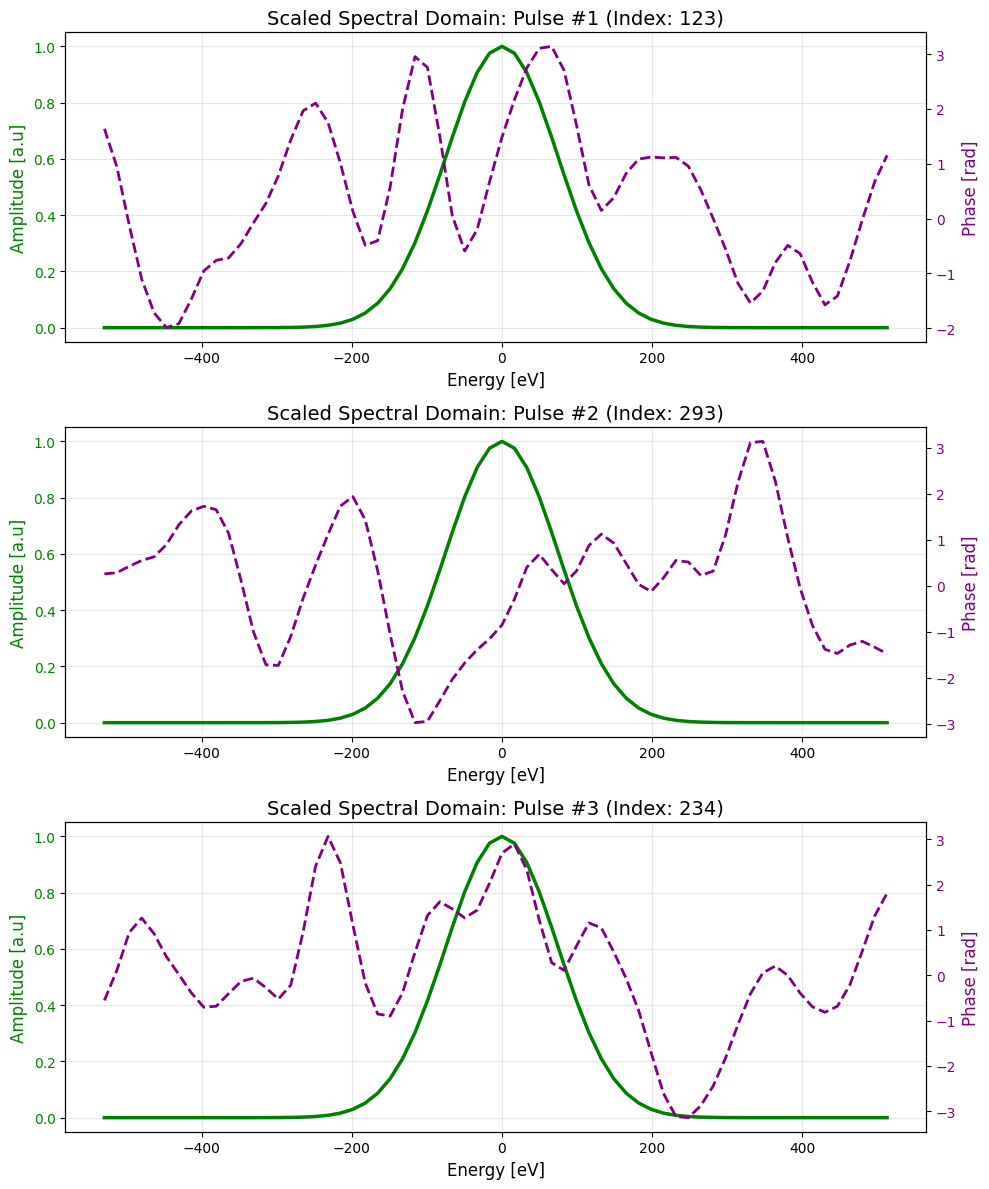

גבולות הספקטרום מוכלים בחלון ספקטרלי שגודלו: 1058.71 Energy [eV]


In [47]:
# ==========================================
# שרטוט הפולסים במרחב התדר על ציר X מותאם (Scaled)
# ==========================================

# 1. שליטה בסקאלה של ציר X (למשל 0.6582 להמרה ל-eV)
scale_factor = 658.2
x_scaled = w_vec * scale_factor

# 2. הגדרת שם היחידות החדשות שיוצגו בגרף
x_axis_label = 'Energy [eV]'

fig_w, axes_w = plt.subplots(3, 1, figsize=(10, 12))

for i, idx in enumerate(random_indices):
    pulse_w = dataset_w[idx]

    # חישוב האמפליטודה והפאזה הספקטרלית
    amplitude_w = np.abs(pulse_w)
    phase_w = np.unwrap(np.angle(pulse_w))

    ax1 = axes_w[i]
    ax2 = ax1.twinx()

    # שרטוט כנגד ציר ה-X המותאם (x_scaled)
    ax1.plot(x_scaled, amplitude_w, color='green', linewidth=2.5, label='Spectral Amplitude')
    ax1.set_ylabel('Amplitude [a.u]', color='green', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='green')

    ax2.plot(x_scaled, phase_w, color='purple', linestyle='--', linewidth=2, label='Spectral Phase')
    ax2.set_ylabel('Phase [rad]', color='purple', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='purple')

    ax1.set_title(f'Scaled Spectral Domain: Pulse #{i+1} (Index: {idx})', fontsize=14)
    ax1.set_xlabel(x_axis_label, fontsize=12)
    ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# חישוב גודל החלון הספקטרלי
spectral_window_size = 2*(np.pi / dt_as) * scale_factor
print(f"גבולות הספקטרום מוכלים בחלון ספקטרלי שגודלו: {spectral_window_size:.2f} {x_axis_label}")

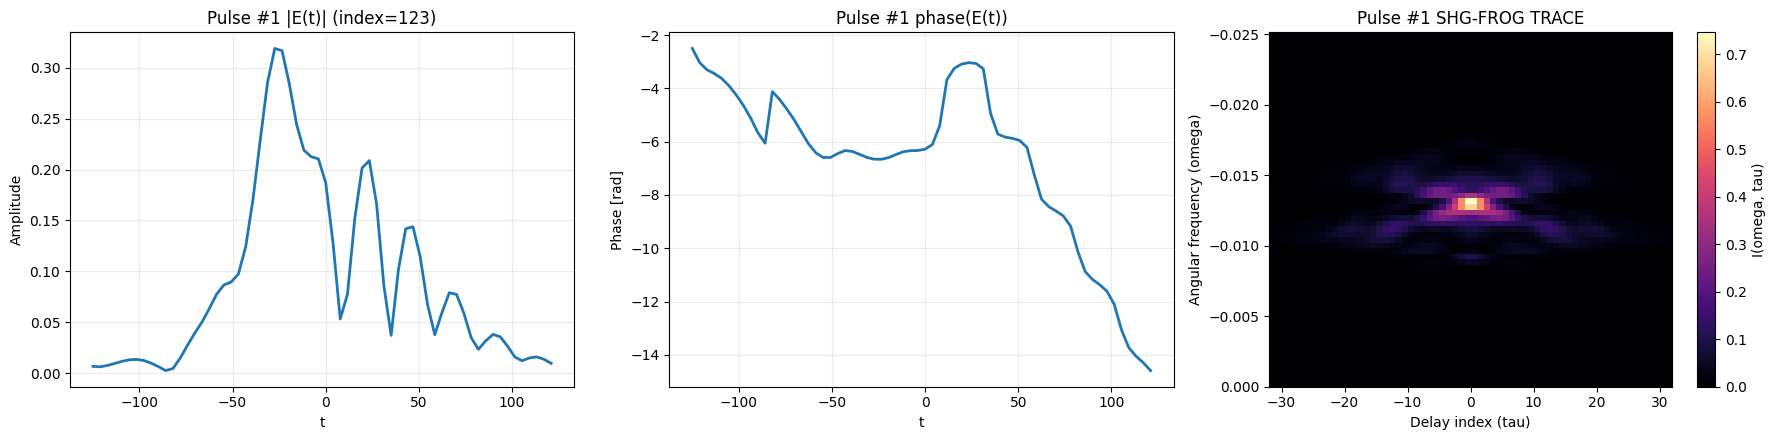

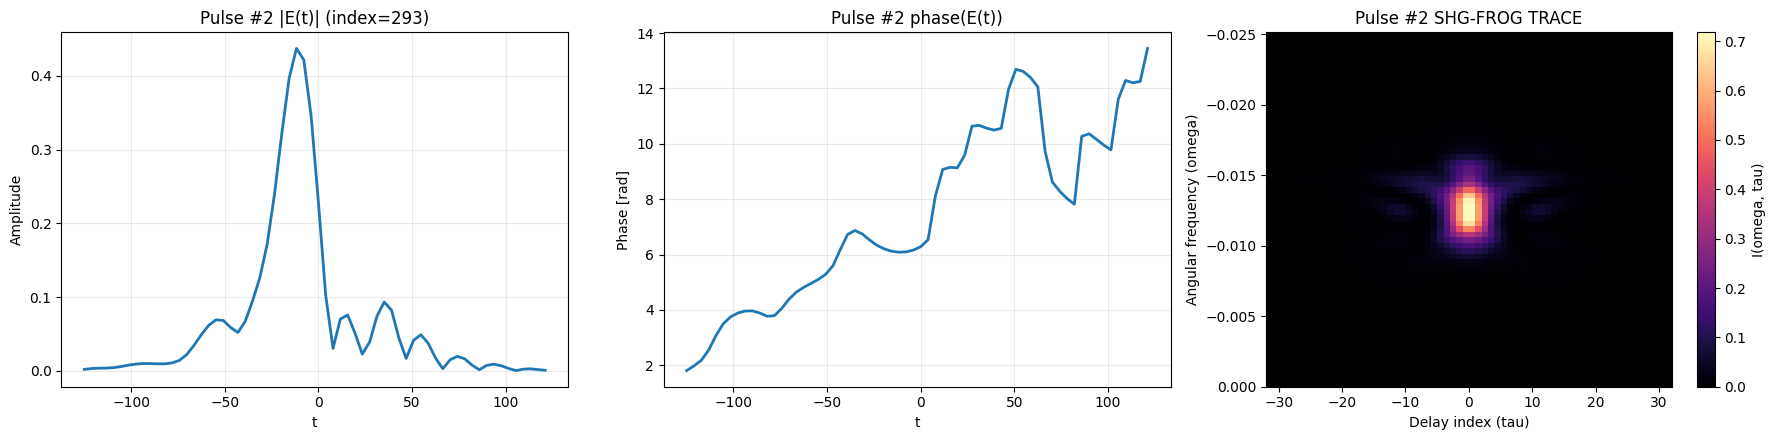

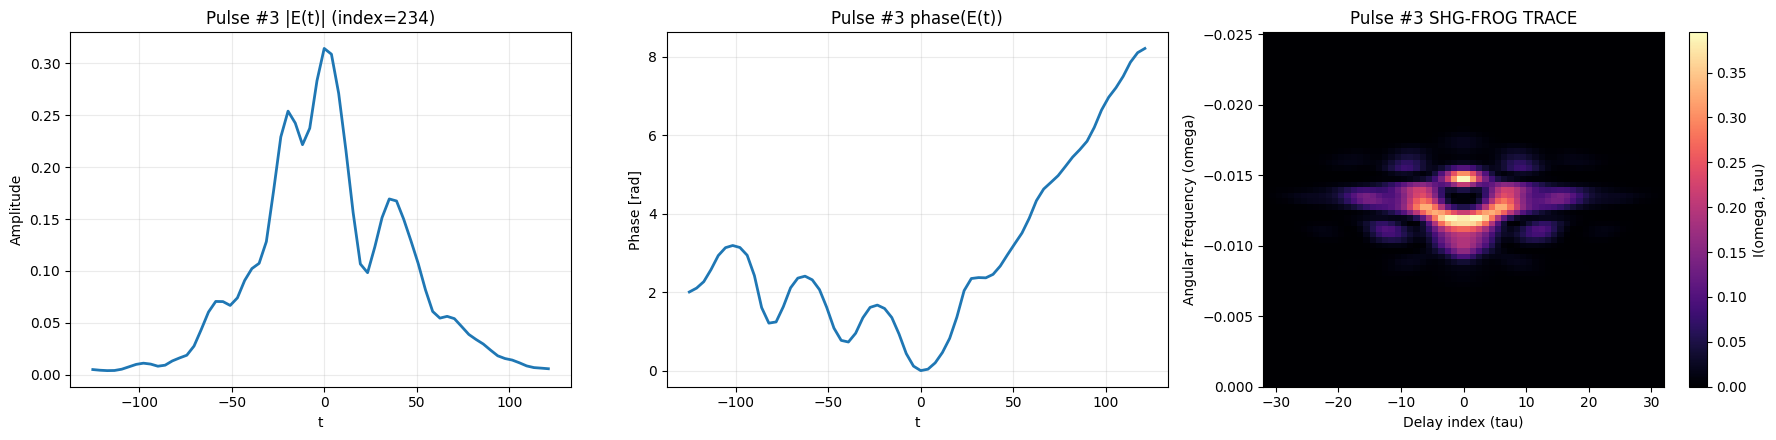

Replay finished for random_indices: [123, 293, 234]


In [48]:
# === Same pulses as the twin-axis cell (`random_indices`), plotted like the TRACE sanity cell ===
# Run the cell that defines `random_indices` before this one.

import numpy as np
import torch
import matplotlib.pyplot as plt

from frognet import FROGNet

num_tau = len(t_vec)
frog = FROGNet(num_delay_steps=num_tau)
frog.eval()

for i, idx in enumerate(random_indices, start=1):
    pulse_t = dataset_t[idx]

    e_t_torch = torch.from_numpy(pulse_t.astype(np.complex64)).unsqueeze(0)

    with torch.no_grad():
        trace = frog(e_t_torch).squeeze(0).cpu().numpy()

    trace_plot = np.fft.fftshift(trace, axes=0)
    omega_plot = np.fft.fftshift(w_vec)

    amp_t = np.abs(pulse_t)
    phase_t = np.unwrap(np.angle(pulse_t))

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

    axes[0].plot(t_vec, amp_t, lw=2)
    axes[0].set_title(f"Pulse #{i} |E(t)| (index={idx})")
    axes[0].set_xlabel("t")
    axes[0].set_ylabel("Amplitude")
    axes[0].grid(alpha=0.25)

    axes[1].plot(t_vec, phase_t, lw=2)
    axes[1].set_title(f"Pulse #{i} phase(E(t))")
    axes[1].set_xlabel("t")
    axes[1].set_ylabel("Phase [rad]")
    axes[1].grid(alpha=0.25)

    tau_axis = np.linspace(-len(t_vec) // 2, len(t_vec) // 2, num_tau)
    im = axes[2].imshow(
        trace_plot,
        origin="lower",
        aspect="auto",
        extent=[tau_axis[0], tau_axis[-1], omega_plot[0], omega_plot[-1]],
        cmap="magma",
    )
    axes[2].set_title(f"Pulse #{i} SHG-FROG TRACE")
    axes[2].set_xlabel("Delay index (tau)")
    axes[2].set_ylabel("Angular frequency (omega)")
    fig.colorbar(im, ax=axes[2], label="I(omega, tau)")

    plt.tight_layout()
    plt.show()

print("Replay finished for random_indices:", random_indices)


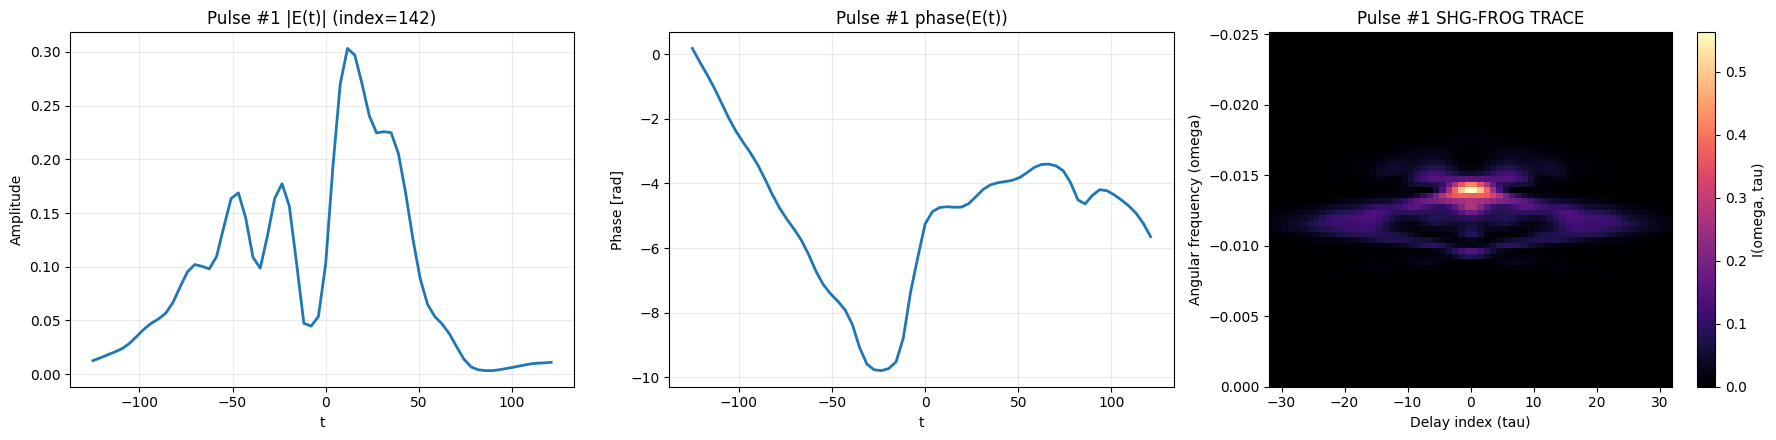

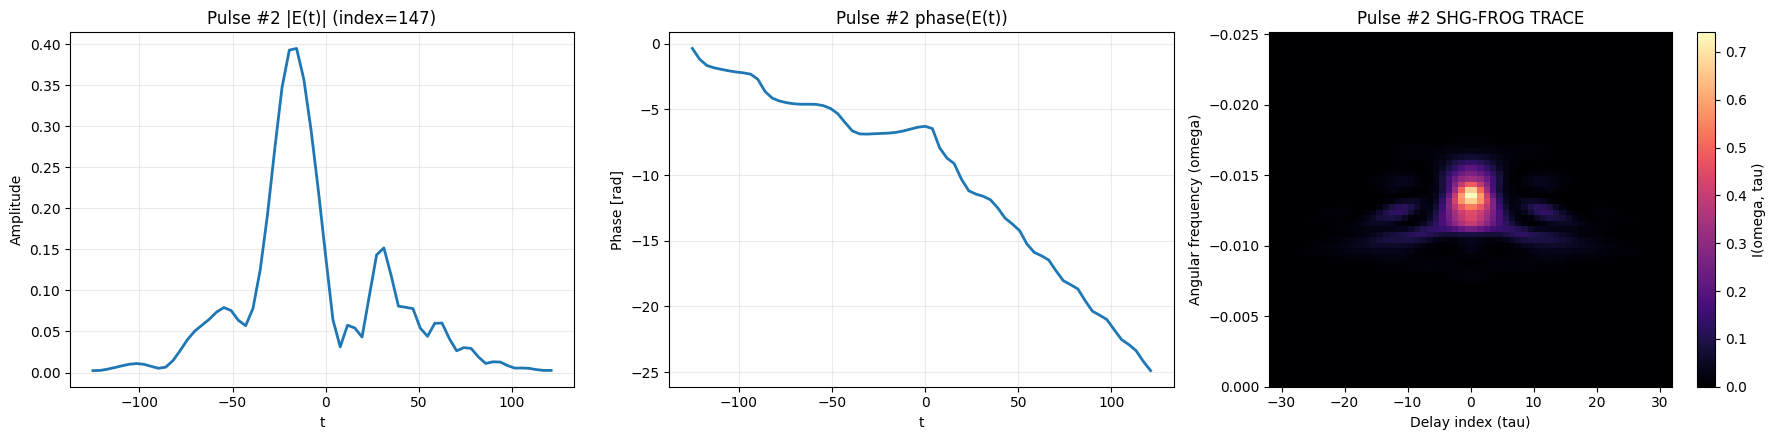

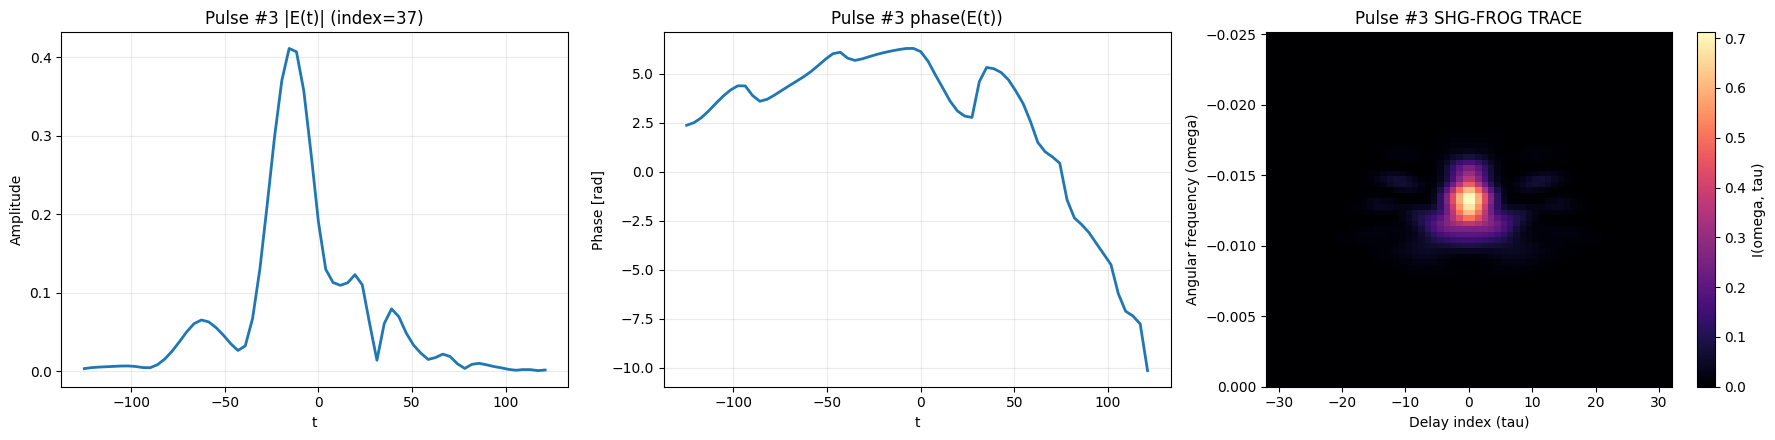

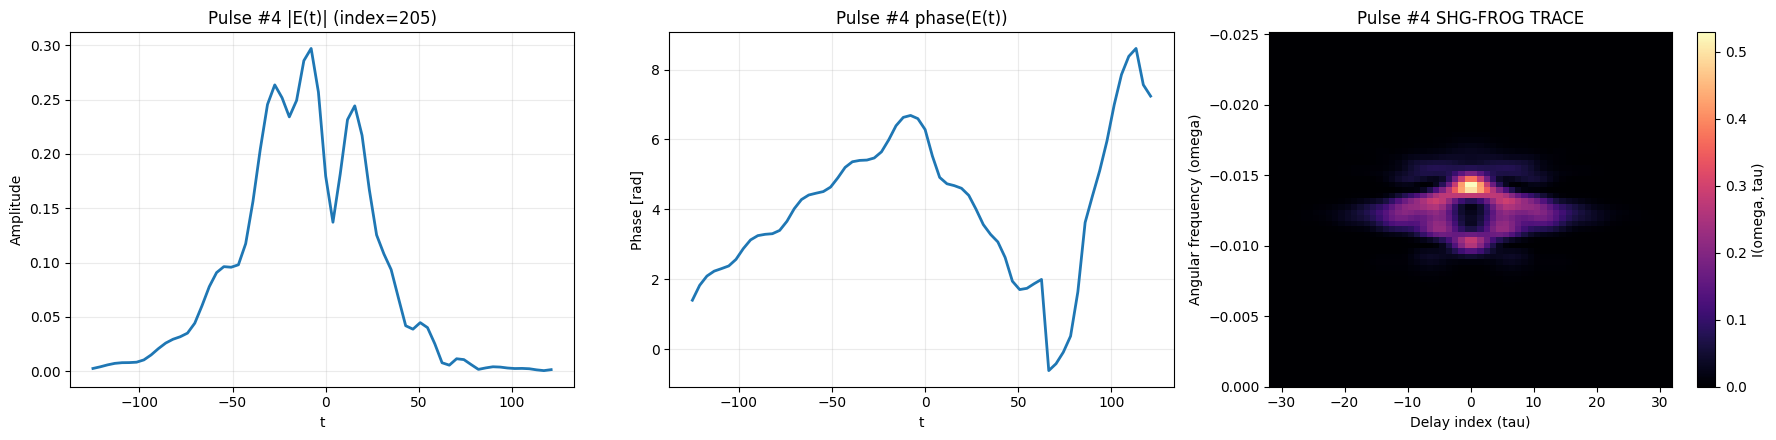

Sanity check finished for indices: [142, 147, 37, 205]
If needed, rerun this cell to sample different pulses.


In [49]:
# === SHG-FROG sanity check on random pulses ===
# This cell assumes dataset_t, t_vec and w_vec were created in previous cells.

import random
import numpy as np
import torch
import matplotlib.pyplot as plt

from frognet import FROGNet

# Choose how many random examples to inspect.
num_examples = 4  # recommended: 3-5
num_tau = len(t_vec)  # keep same as time-grid size for a full trace

# Build model once.
frog = FROGNet(num_delay_steps=num_tau)
frog.eval()

# Random sample indices.
indices = random.sample(range(len(dataset_t)), num_examples)

for i, idx in enumerate(indices, start=1):
    pulse_t = dataset_t[idx]  # complex E(t), shape [N]

    # Convert to torch batch shape [B, N] complex.
    e_t_torch = torch.from_numpy(pulse_t.astype(np.complex64)).unsqueeze(0)

    with torch.no_grad():
        trace = frog(e_t_torch).squeeze(0).cpu().numpy()  # [N_omega, N_tau]

    # FROGNet uses unshifted FFT ordering along omega; shift only for plotting.
    trace_plot = np.fft.fftshift(trace, axes=0)
    omega_plot = np.fft.fftshift(w_vec)

    amp_t = np.abs(pulse_t)
    phase_t = np.unwrap(np.angle(pulse_t))

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

    # |E(t)|
    axes[0].plot(t_vec, amp_t, lw=2)
    axes[0].set_title(f"Pulse #{i} |E(t)| (index={idx})")
    axes[0].set_xlabel("t")
    axes[0].set_ylabel("Amplitude")
    axes[0].grid(alpha=0.25)

    # phase(E(t))
    axes[1].plot(t_vec, phase_t, lw=2)
    axes[1].set_title(f"Pulse #{i} phase(E(t))")
    axes[1].set_xlabel("t")
    axes[1].set_ylabel("Phase [rad]")
    axes[1].grid(alpha=0.25)

    # I(w, tau)
    # Build a symmetric delay axis in sample units to match frognet delay construction.
    tau_axis = np.linspace(-len(t_vec) // 2, len(t_vec) // 2, num_tau)
    im = axes[2].imshow(
        trace_plot,
        origin="lower",
        aspect="auto",
        extent=[tau_axis[0], tau_axis[-1], omega_plot[0], omega_plot[-1]],
        cmap="magma",
    )
    axes[2].set_title(f"Pulse #{i} SHG-FROG TRACE")
    axes[2].set_xlabel("Delay index (tau)")
    axes[2].set_ylabel("Angular frequency (omega)")
    fig.colorbar(im, ax=axes[2], label="I(omega, tau)")

    plt.tight_layout()
    plt.show()

print("Sanity check finished for indices:", indices)
print("If needed, rerun this cell to sample different pulses.")

In [50]:
# === Minimal automatic TRACE checks (requested) ===
# Checks only:
# 1) finite values (no NaN/Inf)
# 2) non-negativity with small numerical tolerance
# 3) consistent shape for all pulses

import numpy as np
import torch

from frognet import FROGNet

# Numerical tolerance for tiny negative values due to floating-point roundoff.
neg_tol = 1e-10

num_tau = len(t_vec)
frog = FROGNet(num_delay_steps=num_tau)
frog.eval()

expected_shape = None
failed = []

for idx in range(len(dataset_t)):
    pulse_t = dataset_t[idx]
    e_t_torch = torch.from_numpy(pulse_t.astype(np.complex64)).unsqueeze(0)

    with torch.no_grad():
        trace = frog(e_t_torch).squeeze(0).cpu().numpy()

    # (3) consistent shape check
    if expected_shape is None:
        expected_shape = trace.shape
    shape_ok = (trace.shape == expected_shape)

    # (1) finite values check
    finite_ok = np.isfinite(trace).all()

    # (2) non-negativity check with tolerance
    nonneg_ok = (trace.min() >= -neg_tol)

    if not (shape_ok and finite_ok and nonneg_ok):
        failed.append({
            "index": idx,
            "shape": trace.shape,
            "shape_ok": shape_ok,
            "finite_ok": finite_ok,
            "nonneg_ok": nonneg_ok,
            "min_value": float(trace.min()),
        })

print(f"Checked {len(dataset_t)} traces")
print(f"Expected shape: {expected_shape}")
print(f"Failures: {len(failed)}")

if failed:
    print("First failures:")
    for item in failed[:10]:
        print(item)
else:
    print("All requested checks passed.")

Checked 300 traces
Expected shape: (64, 64)
Failures: 0
All requested checks passed.


In [ ]:
# === Automatic check: phase(t=0) over all generated pulses ===
# Run after the dataset generation cell.

zero_index = len(t_vec) // 2
phase_t0 = np.angle(dataset_t[:, zero_index])
abs_phase_t0 = np.abs(phase_t0)

max_abs = float(np.max(abs_phase_t0))
mean_abs = float(np.mean(abs_phase_t0))
all_ok = bool(np.all(np.isclose(phase_t0, 0.0, atol=1e-10)))

print(f"Checked pulses: {len(dataset_t)}")
print(f"max |phase(t=0)|: {max_abs:.3e} rad")
print(f"mean |phase(t=0)|: {mean_abs:.3e} rad")
print(f"All pulses satisfy phase(t=0)=0 (atol=1e-10): {all_ok}")